In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('../data/PS_20174392719_1491204439457_log.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (6362620, 11)

First 5 rows:


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [2]:
# Check fraud distribution
print("Fraud distribution:")
print(df['isFraud'].value_counts())
print("\nFraud percentage:")
print(df['isFraud'].value_counts(normalize=True) * 100)

Fraud distribution:
isFraud
0    6354407
1       8213
Name: count, dtype: int64

Fraud percentage:
isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64


In [3]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Check data types
print("\nData types:")
print(df.dtypes)

Missing values:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Data types:
step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object


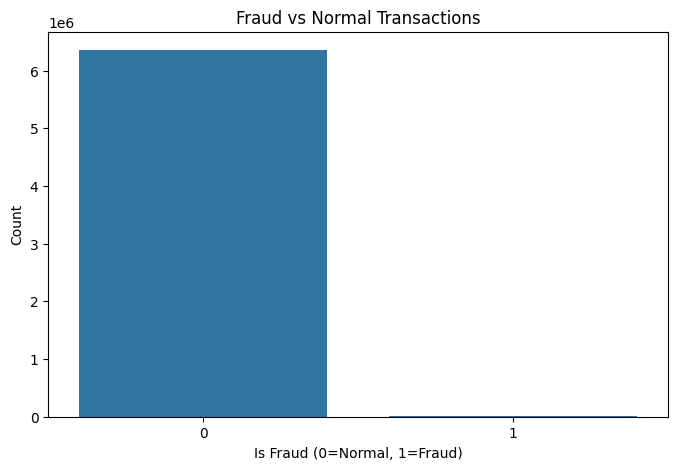

In [4]:
# Visualize fraud vs normal
plt.figure(figsize=(8, 5))
sns.countplot(x='isFraud', data=df)
plt.title('Fraud vs Normal Transactions')
plt.xlabel('Is Fraud (0=Normal, 1=Fraud)')
plt.ylabel('Count')
plt.show()

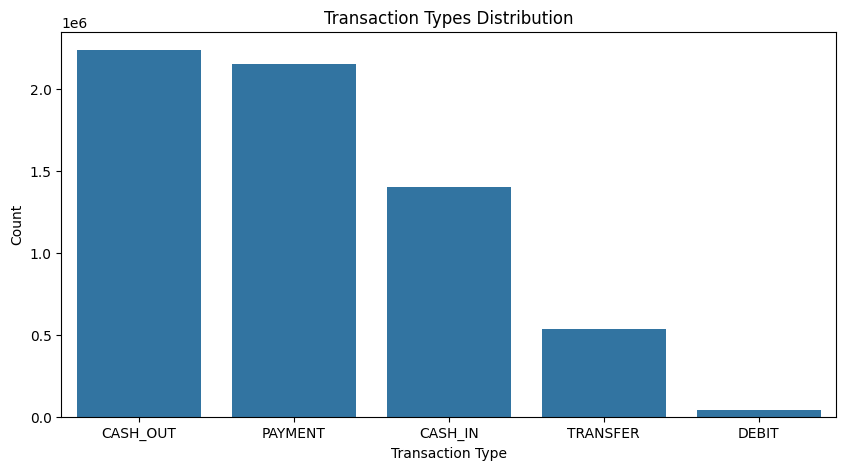

In [5]:
# Transaction types distribution
plt.figure(figsize=(10, 5))
sns.countplot(x='type', data=df, order=df['type'].value_counts().index)
plt.title('Transaction Types Distribution')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.show()

In [6]:
# Which transaction types have fraud?
print("Fraud by transaction type:")
print(df.groupby('type')['isFraud'].sum())

Fraud by transaction type:
type
CASH_IN        0
CASH_OUT    4116
DEBIT          0
PAYMENT        0
TRANSFER    4097
Name: isFraud, dtype: int64


In [7]:
# Save clean summary stats
print("Dataset Summary:")
print(f"Total transactions: {len(df):,}")
print(f"Fraud transactions: {df['isFraud'].sum():,}")
print(f"Fraud rate: {df['isFraud'].mean()*100:.2f}%")
print(f"Fraud only in: CASH_OUT and TRANSFER")

Dataset Summary:
Total transactions: 6,362,620
Fraud transactions: 8,213
Fraud rate: 0.13%
Fraud only in: CASH_OUT and TRANSFER
